## 1. Import Libraries

In [1]:
# Load libraries
import os, sys #os dung de doc duong dan file, tao xoa thu muc kiem tra file ton tai,sys lay tham so dong lenh vaf dung thoat chuong trinh
from IPython import display # dung cho viec hien hinh anh
import numpy as np
import matplotlib.pyplot as plt # ve do thi 
import pandas as pd # dung su ly du lieu dang bang doc , loc du lieu tu csv excel
import seaborn as sns # ve bieu do nang cao
import joblib # luu va load mo hinh machine learning

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder # chuyen du lieu thanh vecto ,text thanh so, du lieu thu tu
from sklearn.preprocessing import MinMaxScaler, StandardScaler # chuan hoa du lieu tu 0 ->1,Chuẩn hóa dữ liệu theo mean = 0 và std = 1
from sklearn.model_selection import train_test_split # chia va train/ test

import warnings

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

## 2. Load Dataset

In [2]:
data_path = "data/pima-indians-diabetes.csv"

data_names = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df_dataset = pd.read_csv(data_path, names=data_names)
df_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Mối quan hệ giữa các tính chất 

**Phân bố của từng biến số**

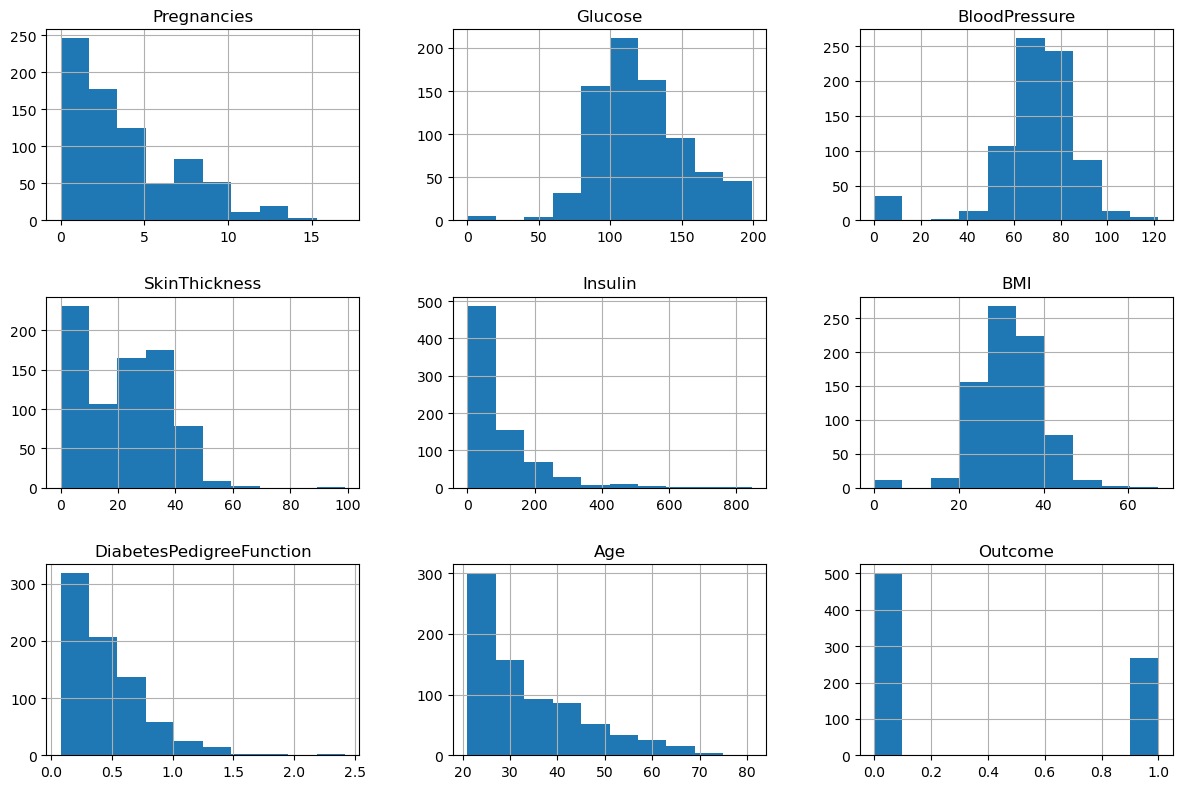

In [3]:
axes = df_dataset.hist(figsize=(12, 8), bins=10, sharex=False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.3)

plt.show()

**Đặc điểm nhóm bệnh nhân và nhóm khỏe mạnh**

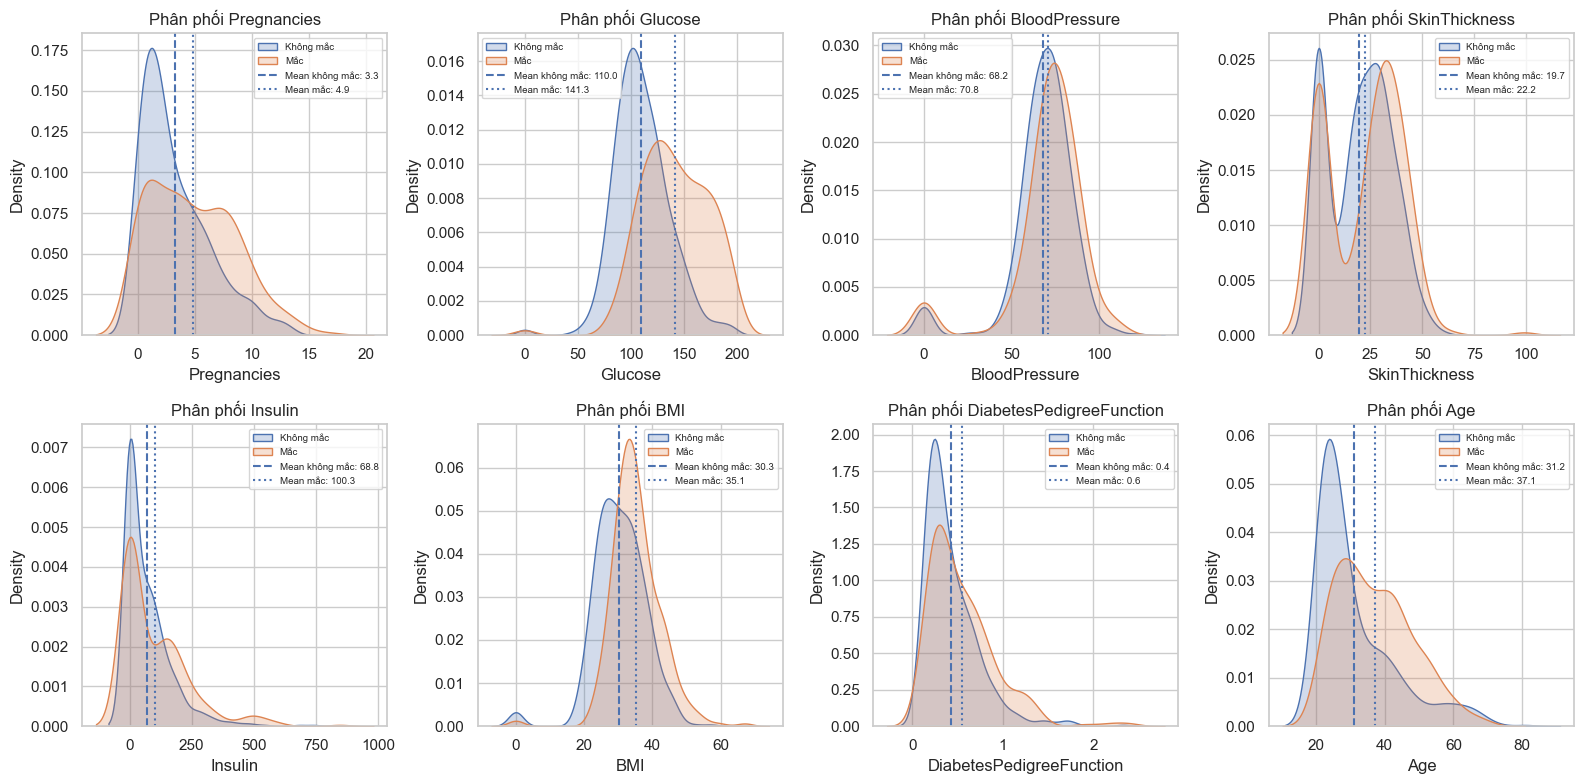

In [4]:

sns.set(style="whitegrid")

# Bỏ cột label ra danh sách riêng
features = df_dataset.columns.drop("Outcome")

# Tạo subplot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    
    # Tách 2 nhóm
    data_0 = df_dataset[df_dataset["Outcome"] == 0][col]
    data_1 = df_dataset[df_dataset["Outcome"] == 1][col]
    
    # KDE plot
    sns.kdeplot(data_0, ax=ax, label="Không mắc", fill=True)
    sns.kdeplot(data_1, ax=ax, label="Mắc", fill=True)
    
    # Mean
    mean_0 = data_0.mean()
    mean_1 = data_1.mean()
    
    ax.axvline(mean_0, linestyle="--", label=f"Mean không mắc: {mean_0:.1f}")
    ax.axvline(mean_1, linestyle=":", label=f"Mean mắc: {mean_1:.1f}")
    
    # Title
    ax.set_title(f"Phân phối {col}")
    ax.legend(fontsize=7)

# Xóa ô thừa nếu có
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Tỷ lệ mắc bệnh đái tháo đường trong dataset

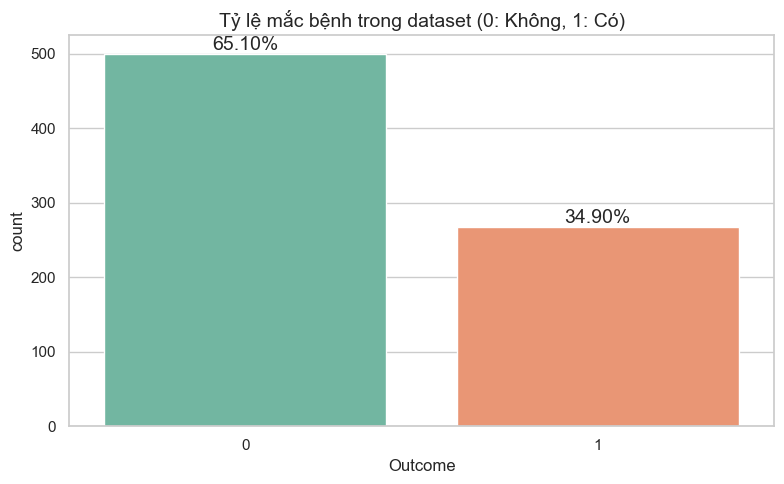

In [5]:


# Đếm số lượng từng lớp
counts = df_dataset["Outcome"].value_counts().sort_index()

# Tính phần trăm
percent = counts / counts.sum() * 100

# Vẽ biểu đồ
plt.figure(figsize=(8,5))
sns.barplot(x=counts.index, y=counts.values, palette=["#66c2a5", "#fc8d62"])

# Thêm % lên đầu cột
for i, value in enumerate(counts.values):
    plt.text(i, value + 5, f"{percent[i]:.2f}%", ha='center', fontsize=14)

# Tiêu đề và nhãn
plt.title("Tỷ lệ mắc bệnh trong dataset (0: Không, 1: Có)", fontsize=14)
plt.xlabel("Outcome")
plt.ylabel("count")

plt.tight_layout()
plt.show()

**Phân bố bệnh theo độ tuổi**

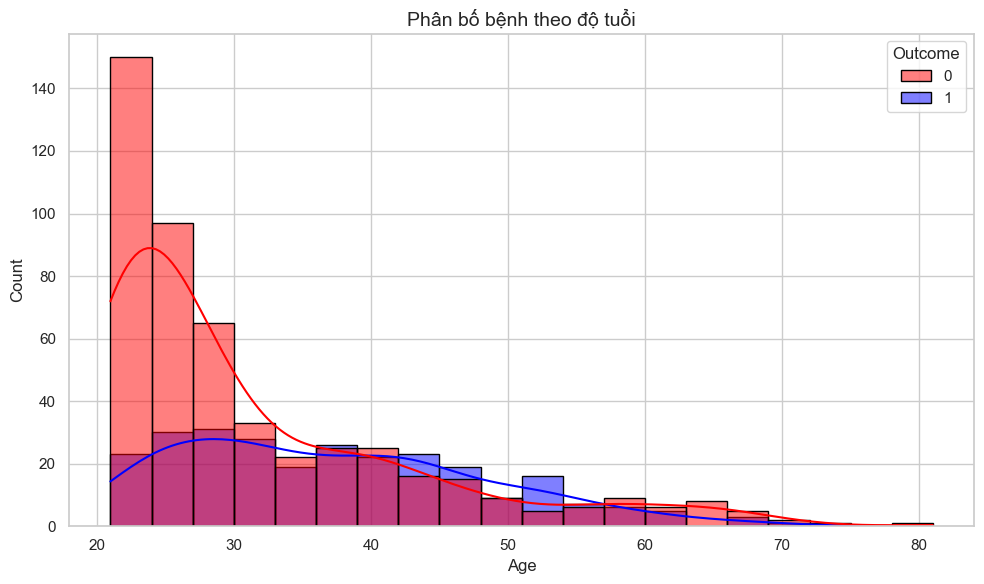

In [6]:

# Style cho đẹp
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))

sns.histplot(
    data=df_dataset,
    x="Age",
    hue="Outcome",       # 🔥 chia theo bệnh / không bệnh
    bins=20,
    kde=True,            # vẽ đường cong mượt
    palette=["red", "blue"],
    alpha=0.5,
    edgecolor="black"
)

plt.title("Phân bố bệnh theo độ tuổi", fontsize=14)
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

ma trận tương quan

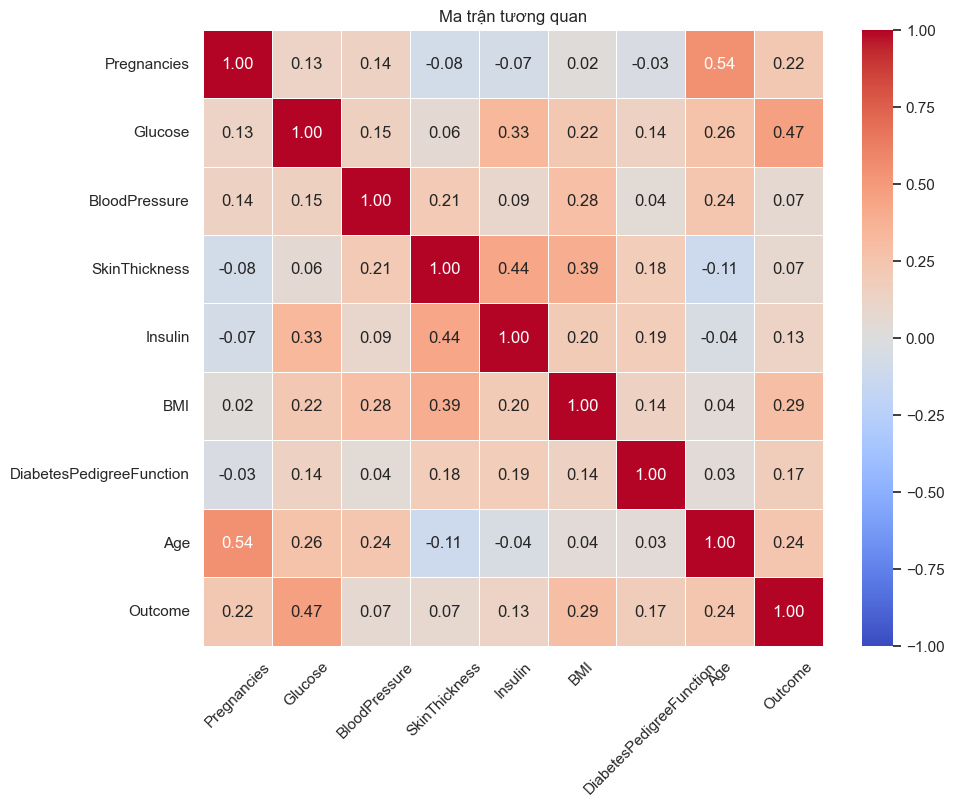

In [7]:

# Tính ma trận tương quan
corr_matrix = df_dataset.corr()

# Vẽ heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Ma trận tương quan")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

**Các chỉ số sinh lý thay đổi theo tuổi**

BMI theo tuổi

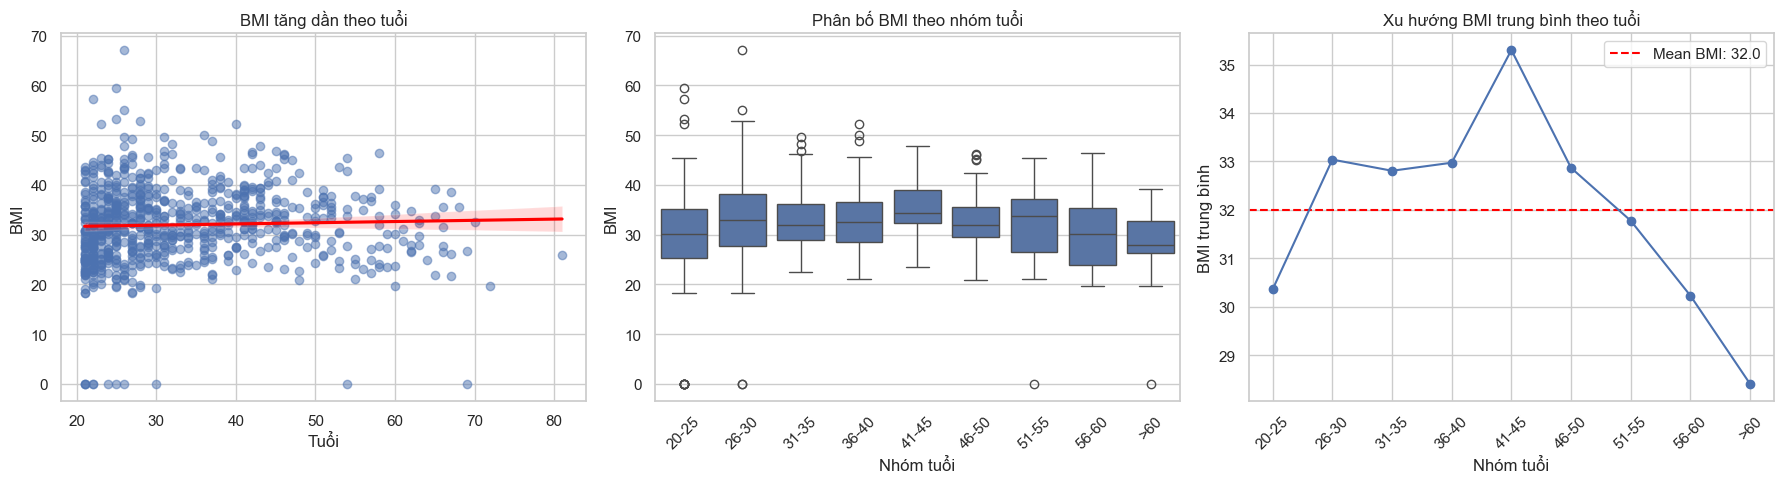

In [8]:


sns.set(style="whitegrid")

# Tạo nhóm tuổi
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 100]
labels = ["20-25","26-30","31-35","36-40","41-45","46-50","51-55","56-60",">60"]

df_dataset["AgeGroup"] = pd.cut(df_dataset["Age"], bins=bins, labels=labels)

# Tạo figure 3 cột
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 🔹 1. Scatter + regression
sns.regplot(
    data=df_dataset,
    x="Age",
    y="BMI",
    ax=axes[0],
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
axes[0].set_title("BMI tăng dần theo tuổi")
axes[0].set_xlabel("Tuổi")
axes[0].set_ylabel("BMI")

# 🔹 2. Boxplot theo nhóm tuổi
sns.boxplot(
    data=df_dataset,
    x="AgeGroup",
    y="BMI",
    ax=axes[1]
)
axes[1].set_title("Phân bố BMI theo nhóm tuổi")
axes[1].set_xlabel("Nhóm tuổi")
axes[1].tick_params(axis='x', rotation=45)

# 🔹 3. Line chart (mean BMI)
mean_bmi = df_dataset.groupby("AgeGroup")["BMI"].mean()
overall_mean = df_dataset["BMI"].mean()

axes[2].axhline(
    overall_mean,
    color='red',
    linestyle='--',
    label=f"Mean BMI: {overall_mean:.1f}"
)
axes[2].plot(mean_bmi.index, mean_bmi.values, marker='o')
axes[2].set_title("Xu hướng BMI trung bình theo tuổi")
axes[2].set_xlabel("Nhóm tuổi")
axes[2].set_ylabel("BMI trung bình")
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()
plt.tight_layout()
plt.show()

Glucose theo tuổi

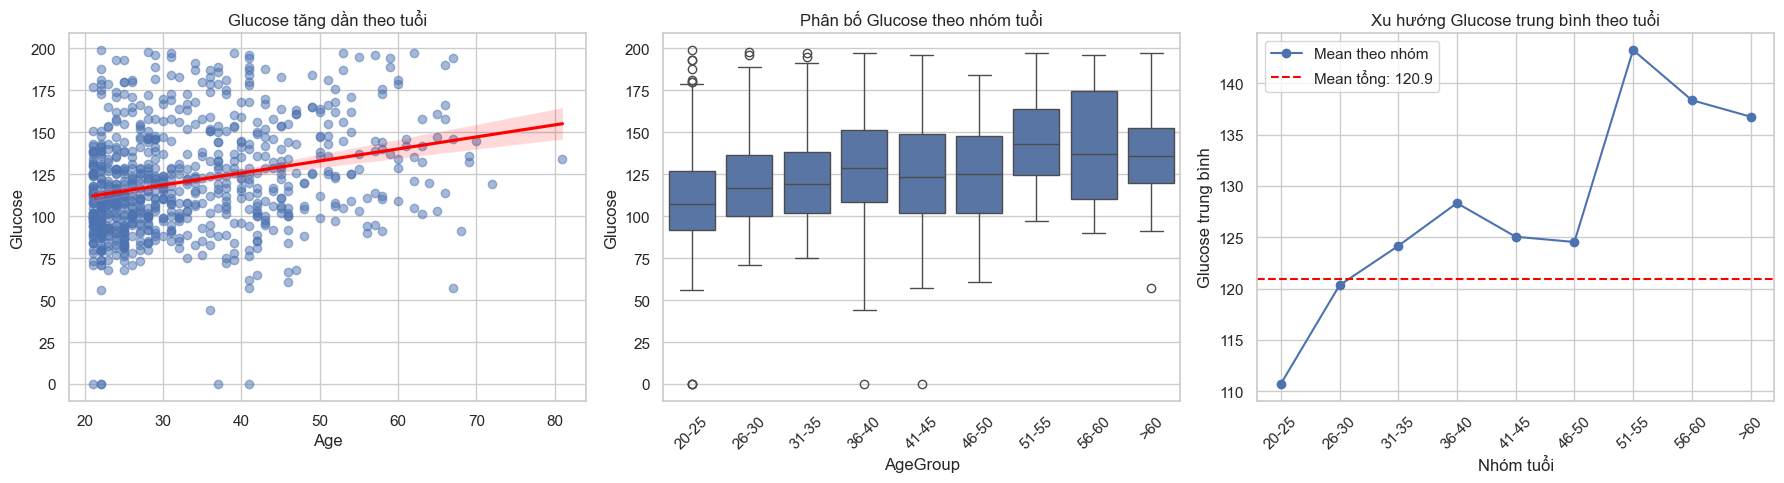

In [9]:
sns.set(style="whitegrid")

# Tạo nhóm tuổi
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 100]
labels = ["20-25","26-30","31-35","36-40","41-45","46-50","51-55","56-60",">60"]

df_dataset["AgeGroup"] = pd.cut(df_dataset["Age"], bins=bins, labels=labels)

# Tạo figure
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1. Scatter + regression
sns.regplot(
    data=df_dataset,
    x="Age",
    y="Glucose",
    ax=axes[0],
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
axes[0].set_title("Glucose tăng dần theo tuổi")

#  2. Boxplot
sns.boxplot(
    data=df_dataset,
    x="AgeGroup",
    y="Glucose",
    ax=axes[1]
)
axes[1].set_title("Phân bố Glucose theo nhóm tuổi")
axes[1].tick_params(axis='x', rotation=45)

#  3. Line chart
mean_glucose = df_dataset.groupby("AgeGroup")["Glucose"].mean()
overall_mean = df_dataset["Glucose"].mean()

axes[2].plot(mean_glucose.index, mean_glucose.values, marker='o', label="Mean theo nhóm")

#  đường trung bình tổng thể
axes[2].axhline(
    overall_mean,
    color='red',
    linestyle='--',
    label=f"Mean tổng: {overall_mean:.1f}"
)

axes[2].set_title("Xu hướng Glucose trung bình theo tuổi")
axes[2].set_xlabel("Nhóm tuổi")
axes[2].set_ylabel("Glucose trung bình")
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

Huyết áp theo tuổi

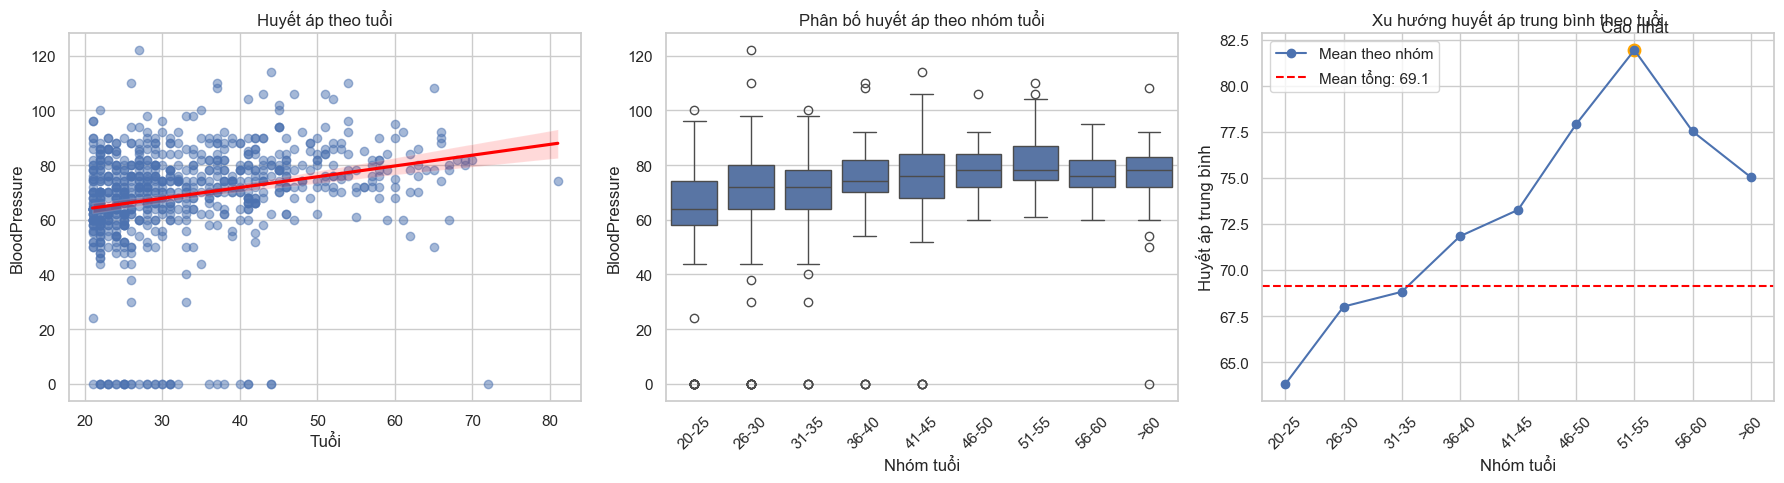

In [10]:


sns.set(style="whitegrid")

# Tạo nhóm tuổi
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 100]
labels = ["20-25","26-30","31-35","36-40","41-45","46-50","51-55","56-60",">60"]

df_dataset["AgeGroup"] = pd.cut(df_dataset["Age"], bins=bins, labels=labels)

# Tạo figure
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 🔹 1. Scatter + regression
sns.regplot(
    data=df_dataset,
    x="Age",
    y="BloodPressure",
    ax=axes[0],
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)
axes[0].set_title("Huyết áp theo tuổi")
axes[0].set_xlabel("Tuổi")
axes[0].set_ylabel("BloodPressure")

# 🔹 2. Boxplot
sns.boxplot(
    data=df_dataset,
    x="AgeGroup",
    y="BloodPressure",
    ax=axes[1]
)
axes[1].set_title("Phân bố huyết áp theo nhóm tuổi")
axes[1].set_xlabel("Nhóm tuổi")
axes[1].tick_params(axis='x', rotation=45)

# 🔹 3. Line chart
mean_bp = df_dataset.groupby("AgeGroup")["BloodPressure"].mean()
overall_mean = df_dataset["BloodPressure"].mean()

axes[2].plot(mean_bp.index, mean_bp.values, marker='o', label="Mean theo nhóm")

# 👉 Đường trung bình tổng
axes[2].axhline(
    overall_mean,
    color='red',
    linestyle='--',
    label=f"Mean tổng: {overall_mean:.1f}"
)

# 👉 Highlight nhóm cao nhất
max_idx = mean_bp.idxmax()
max_val = mean_bp.max()
axes[2].scatter(max_idx, max_val, color='orange', s=80)
axes[2].text(max_idx, max_val+1, "Cao nhất", ha='center')

axes[2].set_title("Xu hướng huyết áp trung bình theo tuổi")
axes[2].set_xlabel("Nhóm tuổi")
axes[2].set_ylabel("Huyết áp trung bình")
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

**Tỷ lệ phân bố theo nhóm tuổi**

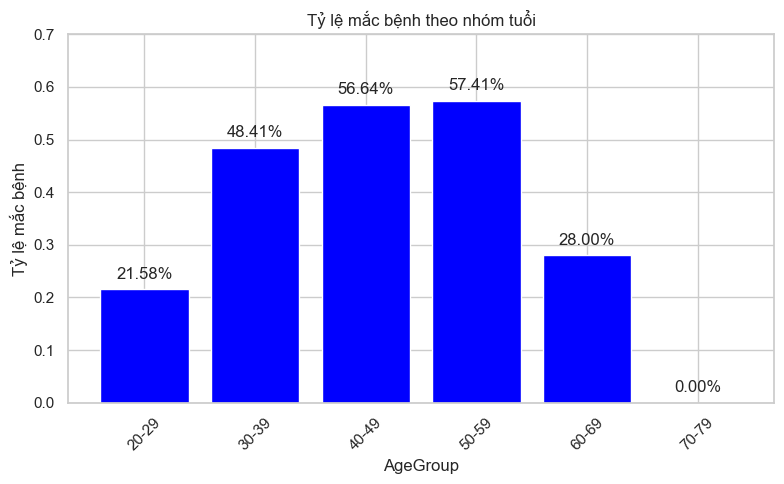

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

#  1. Tạo nhóm tuổi
bins = [20, 30, 40, 50, 60, 70, 80]
labels = ["20-29","30-39","40-49","50-59","60-69","70-79"]

df_dataset["AgeGroup"] = pd.cut(df_dataset["Age"], bins=bins, labels=labels)

#  2. Tính tỷ lệ mắc bệnh
rate = df_dataset.groupby("AgeGroup")["Outcome"].mean()

#  3. Vẽ biểu đồ cột
plt.figure(figsize=(8,5))
plt.bar(rate.index, rate.values, color="blue")

plt.title("Tỷ lệ mắc bệnh theo nhóm tuổi")
plt.xlabel("AgeGroup")
plt.ylabel("Tỷ lệ mắc bệnh")

#  4. Hiển thị % trên cột
for i, v in enumerate(rate):
    plt.text(i, v + 0.02, f"{v*100:.2f}%", ha='center')

plt.xticks(rotation=45)
plt.ylim(0, 0.7)

plt.tight_layout()
plt.show()

Tỷ lệ mắc bệnh theo nhóm BMI

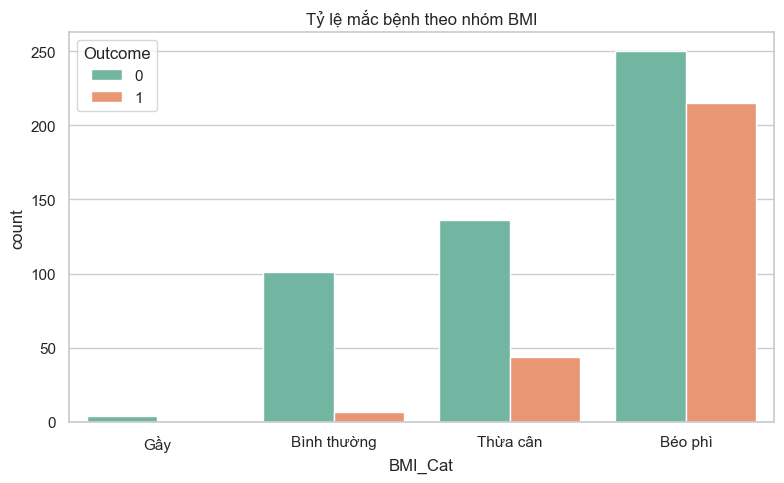

In [12]:

sns.set(style="whitegrid")
#  1. Xử lý BMI (loại giá trị 0)
df_dataset["BMI"] = df_dataset["BMI"].replace(0, pd.NA)
df_dataset["BMI"] = pd.to_numeric(df_dataset["BMI"], errors="coerce")
#  2. Tạo nhóm BMI
bins = [0, 18.5, 25, 30, 100]
labels = ["Gầy", "Bình thường", "Thừa cân", "Béo phì"]

df_dataset["BMI_Cat"] = pd.cut(df_dataset["BMI"], bins=bins, labels=labels)

#  3. Vẽ countplot
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_dataset,
    x="BMI_Cat",
    hue="Outcome",
    palette="Set2"
)

plt.title("Tỷ lệ mắc bệnh theo nhóm BMI")
plt.xlabel("BMI_Cat")
plt.ylabel("count")

plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

Tỷ lệ mắc bệnh theo nhóm BMI

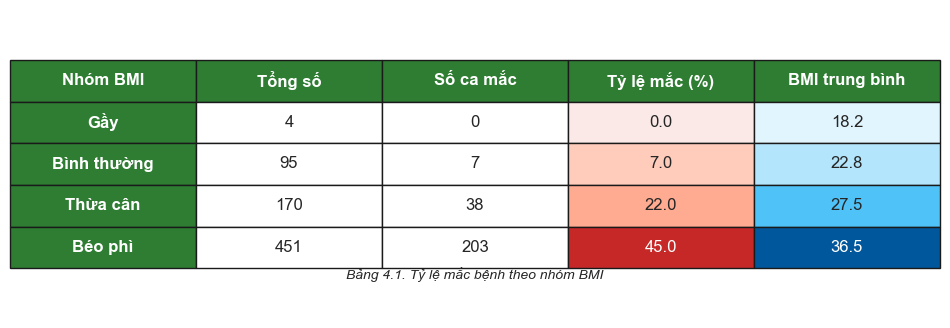

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Giả sử đây là DataFrame 'result' bạn đã tạo ở bước trước
data = {
    "Nhóm BMI": ["Gầy", "Bình thường", "Thừa cân", "Béo phì"],
    "Tổng số": [4, 95, 170, 451],
    "Số ca mắc": [0, 7, 38, 203],
    "Tỷ lệ mắc (%)": [0.0, 7.0, 22.0, 45.0],
    "BMI trung bình": [18.2, 22.8, 27.5, 36.5]
}
df = pd.DataFrame(data)

# 2. Thiết lập vẽ bảng bằng Matplotlib
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')

# Tạo bảng
table = ax.table(cellText=df.values, 
                 colLabels=df.columns, 
                 cellLoc='center', 
                 loc='center')

# 3. Tùy chỉnh định dạng giống trong ảnh
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2.5) # Điều chỉnh độ rộng và chiều cao hàng

# Màu sắc cho tiêu đề (Hàng 0)
header_color = '#2E7D32' # Màu xanh lá đậm
for j in range(len(df.columns)):
    table[0, j].set_facecolor(header_color)
    table[0, j].get_text().set_color('white')
    table[0, j].get_text().set_weight('bold')

# Màu sắc cho cột "Nhóm BMI" (Cột 0)
for i in range(1, len(df) + 1):
    table[i, 0].set_facecolor(header_color)
    table[i, 0].get_text().set_color('white')
    table[i, 0].get_text().set_weight('bold')

# 4. Đổ màu Gradient cho cột "Tỷ lệ mắc (%)" (Cột index 3)
# Màu từ cam nhạt đến đỏ đậm
colors_ty_le = ['#FBE9E7', '#FFCCBC', '#FFAB91', '#C62828']
for i, color in enumerate(colors_ty_le):
    table[i+1, 3].set_facecolor(color)
    if i == 3: # Hàng béo phì chữ trắng cho dễ đọc trên nền đỏ
        table[i+1, 3].get_text().set_color('white')

# 5. Đổ màu cho cột "BMI trung bình" (Cột index 4)
colors_bmi = ['#E1F5FE', '#B3E5FC', '#4FC3F7', '#01579B']
for i, color in enumerate(colors_bmi):
    table[i+1, 4].set_facecolor(color)
    if i == 3: # Hàng cuối chữ trắng
        table[i+1, 4].get_text().set_color('white')




plt.title("Bảng 4.1. Tỷ lệ mắc bệnh theo nhóm BMI", y=0.1, fontsize=10, fontstyle='italic')
plt.show()

BMI và Glucose theo Outcome

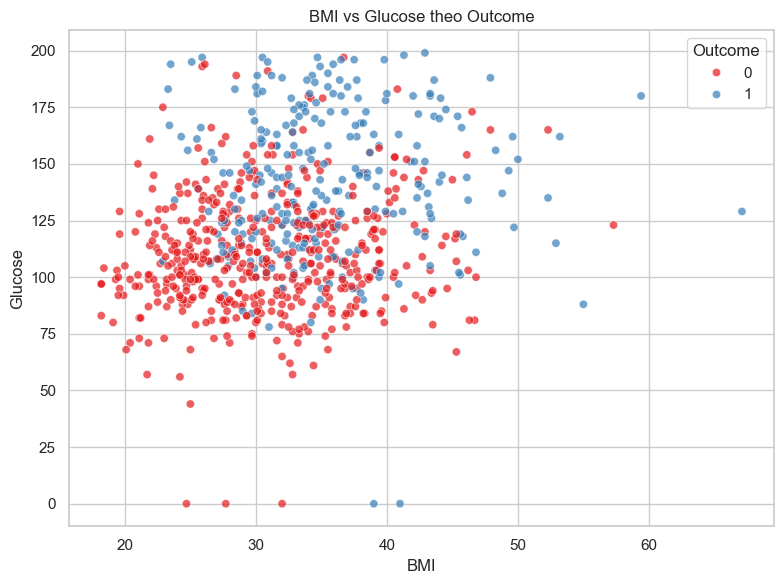

In [ ]:

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dataset,
    x="BMI",
    y="Glucose",
    hue="Outcome",   # phân màu theo bệnh (0,1)
    palette="Set1",  # màu giống hình (xanh + cam)
    alpha=0.7
)

plt.title("BMI vs Glucose theo Outcome")
plt.xlabel("BMI")
plt.ylabel("Glucose")

plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

BMI và Age theo Outcome

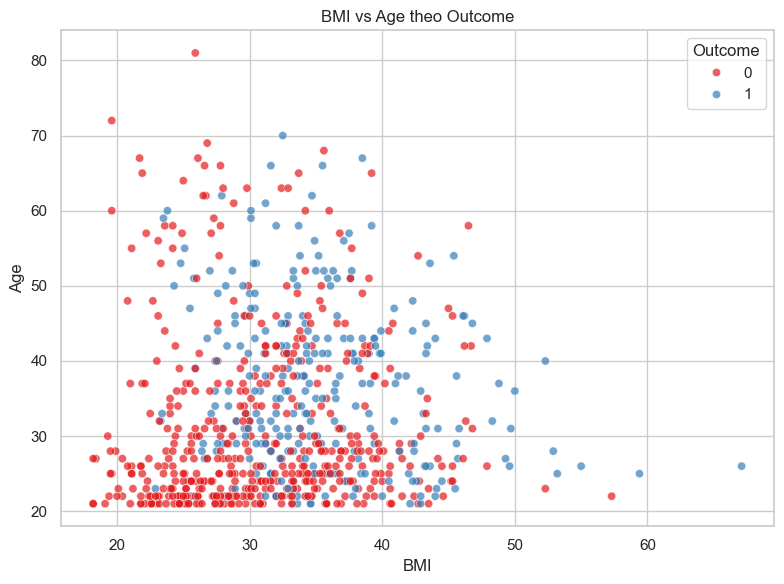

In [ ]:

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dataset,
    x="BMI",
    y="Age",
    hue="Outcome",   # phân màu theo bệnh (0,1)
    palette="Set1",  # màu giống hình (xanh + cam)
    alpha=0.7
)

plt.title("BMI vs Age theo Outcome")
plt.xlabel("BMI")
plt.ylabel("Age")

plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

BMI và Insulin theo Outcome

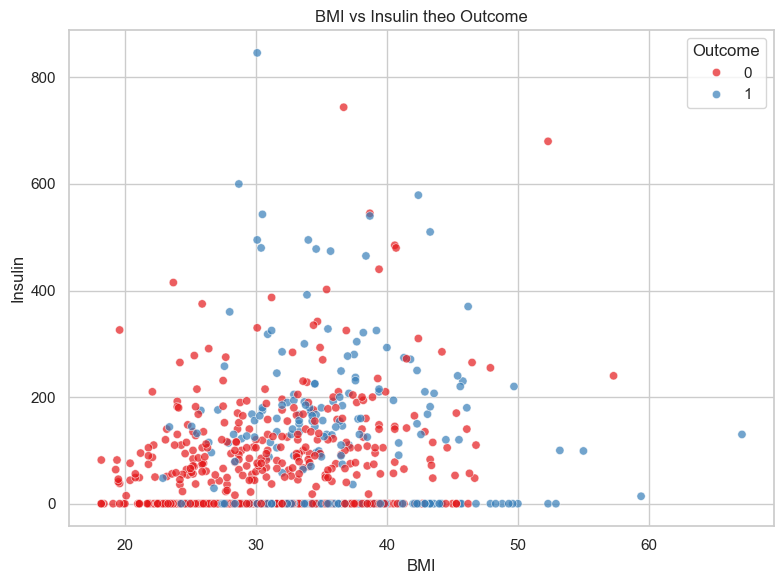

In [ ]:

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dataset,
    x="BMI",
    y="Insulin",
    hue="Outcome",   # phân màu theo bệnh (0,1)
    palette="Set1",  # màu giống hình (xanh + cam)
    alpha=0.7
)

plt.title("BMI vs Insulin theo Outcome")
plt.xlabel("BMI")
plt.ylabel("Insulin")

plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

Phân bố bệnh theo nồng độ Glucose

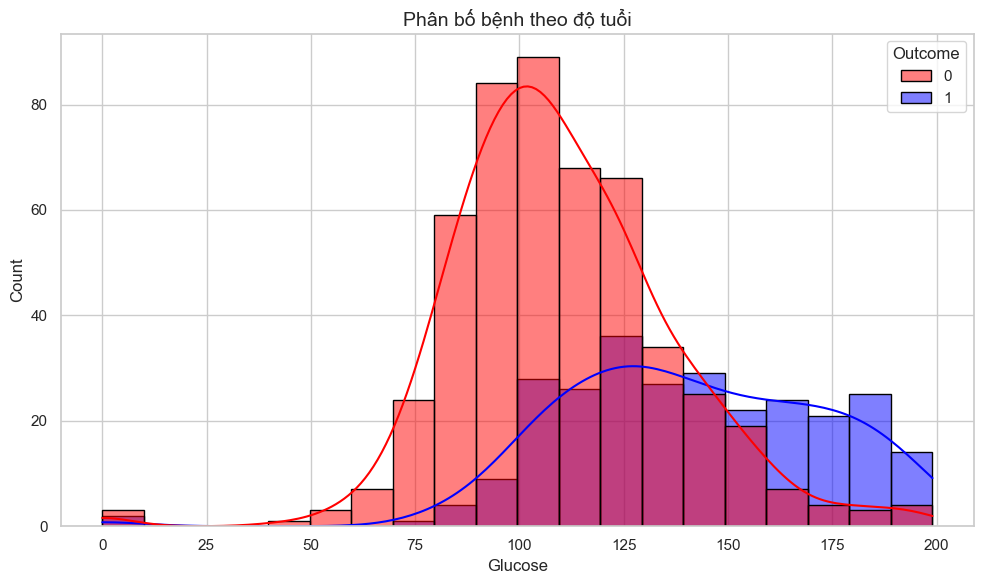

In [ ]:

# Style cho đẹp
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
sns.histplot(
    data=df_dataset,
    x="Glucose",
    hue="Outcome",       # 🔥 chia theo bệnh / không bệnh
    bins=20,
    kde=True,            # vẽ đường cong mượt
    palette=["red", "blue"],
    alpha=0.5,
    edgecolor="black"
)

plt.title("Phân bố bệnh theo độ tuổi", fontsize=14)
plt.xlabel("Glucose")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

Glucose và insulin

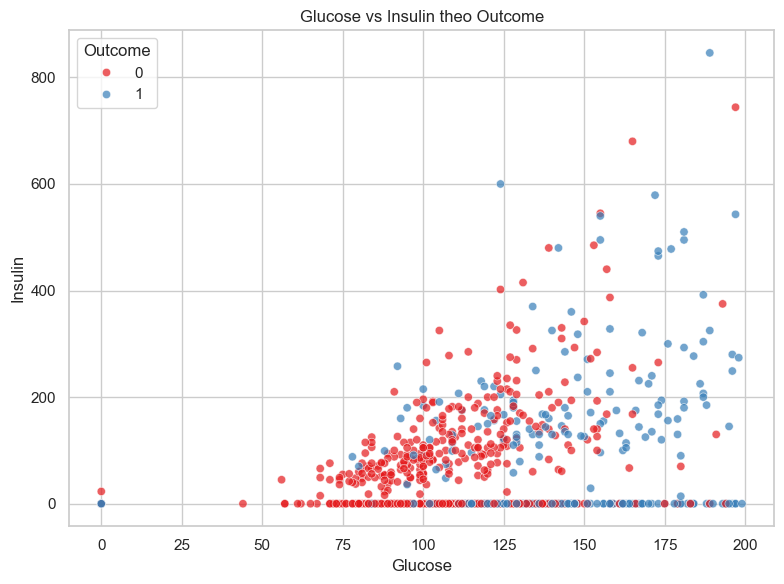

In [ ]:

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dataset,
    x="Glucose",
    y="Insulin",
    hue="Outcome",   # phân màu theo bệnh (0,1)
    palette="Set1",  # màu giống hình (xanh + cam)
    alpha=0.7
)

plt.title("Glucose vs Insulin theo Outcome")
plt.xlabel("Glucose")
plt.ylabel("Insulin")

plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

Phân bố Diabetes Pedigree Function

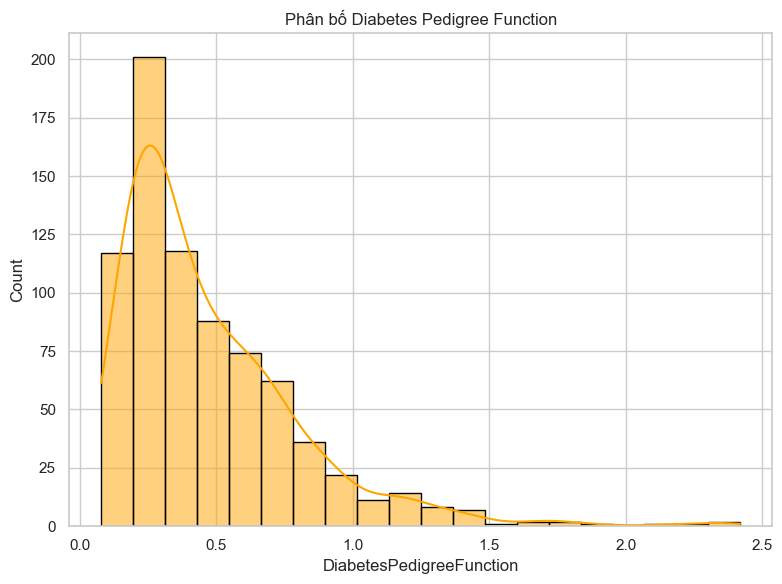

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.histplot(
    data=df_dataset,
    x="DiabetesPedigreeFunction",
    bins=20,
    kde=True,                # vẽ đường cong
    color="orange",
    edgecolor="black"
)

plt.title("Phân bố Diabetes Pedigree Function")
plt.xlabel("DiabetesPedigreeFunction")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

Outcome theo yếu tố di chuyền

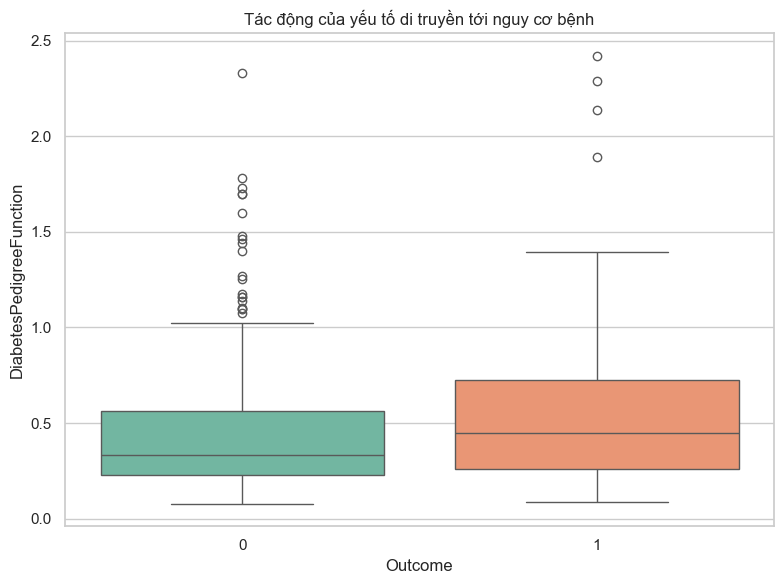

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_dataset,
    x="Outcome",
    y="DiabetesPedigreeFunction",
    palette=["#66c2a5", "#fc8d62"]  # xanh + cam giống hình
)

plt.title("Tác động của yếu tố di truyền tới nguy cơ bệnh")
plt.xlabel("Outcome")
plt.ylabel("DiabetesPedigreeFunction")

plt.tight_layout()
plt.show()

Di truyền kết hợp với Glucose

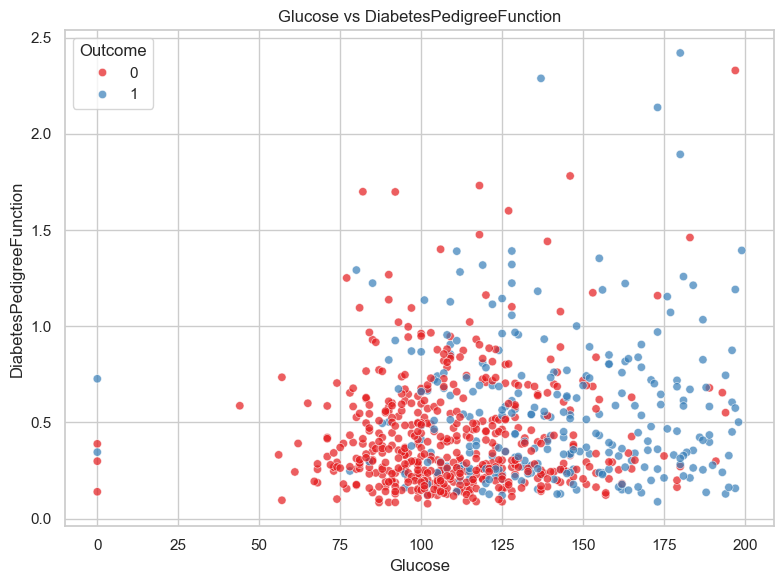

In [ ]:

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_dataset,
    x="Glucose",
    y="DiabetesPedigreeFunction",
    hue="Outcome",   # phân màu theo bệnh (0,1)
    palette="Set1",  # màu giống hình (xanh + cam)
    alpha=0.7
)

plt.title("Glucose vs DiabetesPedigreeFunction")
plt.xlabel("Glucose")
plt.ylabel("DiabetesPedigreeFunction")

plt.legend(title="Outcome")

plt.tight_layout()
plt.show()

Số lần có thai theo Outcome

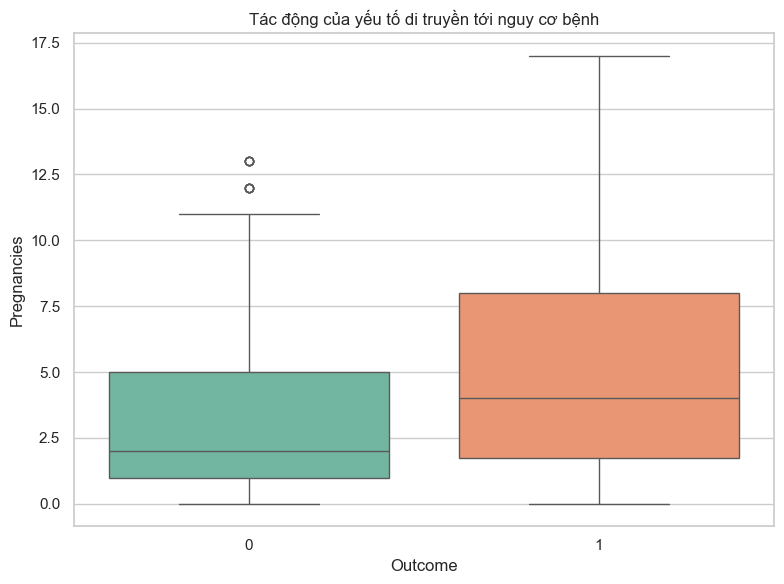

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_dataset,
    x="Outcome",
    y="Pregnancies",
    palette=["#66c2a5", "#fc8d62"]  # xanh + cam giống hình
)

plt.title("Tác động của yếu tố di truyền tới nguy cơ bệnh")
plt.xlabel("Outcome")
plt.ylabel("Pregnancies")

plt.tight_layout()
plt.show()

Nguy cơ đái tháo đường theo số lần có thai

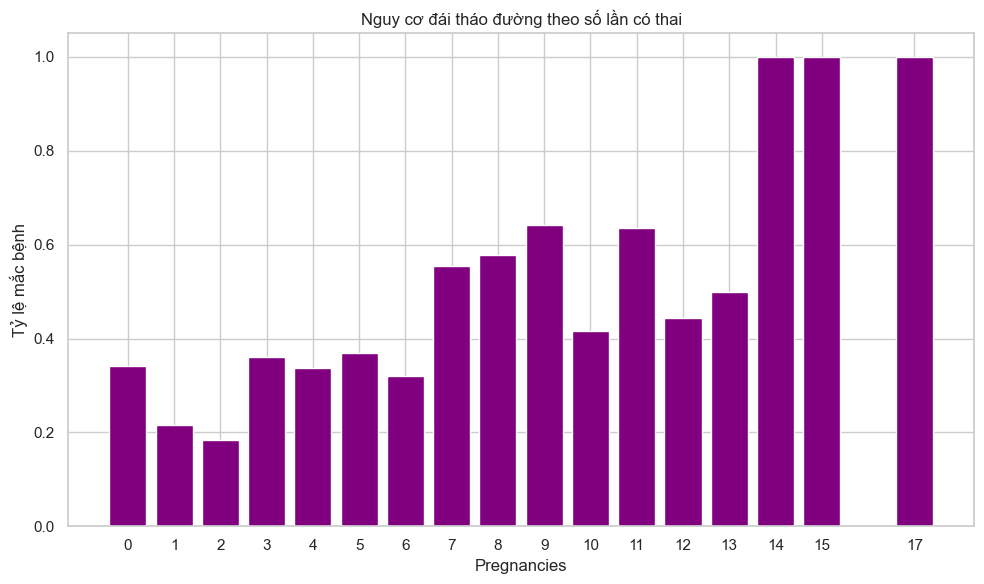

In [ ]:
import matplotlib.pyplot as plt

# 🔹 Tính tỷ lệ mắc bệnh theo số lần mang thai
preg_rate = df_dataset.groupby("Pregnancies")["Outcome"].mean()

plt.figure(figsize=(10,6))

plt.bar(
    preg_rate.index,
    preg_rate.values,
    color="purple"
)

plt.title("Nguy cơ đái tháo đường theo số lần có thai")
plt.xlabel("Pregnancies")
plt.ylabel("Tỷ lệ mắc bệnh")

plt.xticks(preg_rate.index)  # hiện đầy đủ trục x

plt.tight_layout()
plt.show()

In [ ]:
!jupyter nbconvert --to html Ve_bieu_do.ipynb

[NbConvertApp] Converting notebook Ve_bieu_do.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 21 image(s).
[NbConvertApp] Writing 2591005 bytes to Ve_bieu_do.html
